# pyR0compute: examples

Symbolic computation of the basic reproduction number $R_0$ with the next-generation matrix method. Write the ODE model, say which compartments are infected, and every other symbol is recognised as a parameter.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Yvan-BM-Git/pyR0compute/blob/main/examples/pyR0compute_examples.ipynb)

In [1]:
# In Colab or a new environment (use `pip install pyR0compute` once it is on PyPI):
# %pip install -q git+https://github.com/Yvan-BM-Git/pyR0compute
%pip install -q ..
import sympy as sp
from pyr0compute import R0Model
sp.init_printing()

Note: you may need to restart the kernel to use updated packages.


## 1. SEIR with vital dynamics

Only the equations and the infected compartments are given.

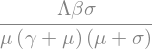

In [2]:
seir = R0Model("""
    dS/dt = Lambda - beta*S*I - mu*S
    dE/dt = beta*S*I - (sigma + mu)*E
    dI/dt = sigma*E - (gamma + mu)*I
    dR/dt = gamma*I - mu*R
""", infected=["E", "I"])

seir.R0

In [3]:
print("Parameters detected:", seir.parameters)
print("Disease-free equilibrium:", seir.dfe)

Parameters detected: (Lambda, beta, gamma, mu, sigma)
Disease-free equilibrium: {S: Lambda/mu, E: 0, I: 0, R: 0}


The whole computation, step by step:

In [6]:
from IPython.display import Markdown, display
display(Markdown(seir.report_latex("markdown")))

## pyR0compute: next-generation matrix method

**Variables:** $S, E, I, R$  
**Infected compartments:** $E, I$  
**Parameters (detected automatically):** $\Lambda, \beta, \gamma, \mu, \sigma$

### Model

$$
\begin{aligned}
\frac{dS}{dt} &= - I S \beta + \Lambda - S \mu \\
\frac{dE}{dt} &= - E \left(\mu + \sigma\right) + I S \beta \\
\frac{dI}{dt} &= E \sigma - I \left(\gamma + \mu\right) \\
\frac{dR}{dt} &= I \gamma - R \mu
\end{aligned}
$$

### New-infection terms (automatic)

$$
\begin{aligned}
\mathcal{F}_{E} &= I S \beta \\
\mathcal{F}_{I} &= 0
\end{aligned}
$$

### Term classification

| Equation | Term | Class | Reason |
|---|---|:---:|---|
| $dE/dt$ | $E \left(- \mu - \sigma\right)$ | $\mathcal{V}$ | negative term |
| $dE/dt$ | $I S \beta$ | $\mathcal{F}$ | transfer from uninfected S |
| $dI/dt$ | $E \sigma$ | $\mathcal{V}$ | transfer from infected E |
| $dI/dt$ | $I \left(- \gamma - \mu\right)$ | $\mathcal{V}$ | negative term |

### Transition terms

$$
\begin{aligned}
\mathcal{V}_{E} &= E \mu + E \sigma \\
\mathcal{V}_{I} &= - E \sigma + I \gamma + I \mu
\end{aligned}
$$

### Disease-free equilibrium

$$
\begin{aligned}
S &= \frac{\Lambda}{\mu} \\
E &= 0 \\
I &= 0 \\
R &= 0
\end{aligned}
$$

### Next-generation matrix

$$
\begin{aligned}
F &= \begin{bmatrix}0 & \frac{\Lambda \beta}{\mu}\\0 & 0\end{bmatrix} \\
V &= \begin{bmatrix}\mu + \sigma & 0\\- \sigma & \gamma + \mu\end{bmatrix} \\
K = F V^{-1} &= \begin{bmatrix}\frac{\Lambda \beta \sigma}{\mu \left(\gamma + \mu\right) \left(\mu + \sigma\right)} & \frac{\Lambda \beta}{\mu \left(\gamma + \mu\right)}\\0 & 0\end{bmatrix}
\end{aligned}
$$

Only $E$ receive new infections, so $\mathcal{R}_0$ is the spectral radius of the next-generation matrix with small domain:

$$
\begin{aligned}
K_{\text{small}} &= \begin{bmatrix}\frac{\Lambda \beta \sigma}{\mu \left(\gamma + \mu\right) \left(\mu + \sigma\right)}\end{bmatrix}
\end{aligned}
$$

### Basic reproduction number

$$
\begin{aligned}
\mathcal{R}_0 = \rho\left(F V^{-1}\right) &= \frac{\Lambda \beta \sigma}{\mu \left(\gamma + \mu\right) \left(\mu + \sigma\right)}
\end{aligned}
$$

In [7]:
print(seir.report_latex())

\section*{pyR0compute: next-generation matrix method}

\textbf{Variables:} $S, E, I, R$ \\
\textbf{Infected compartments:} $E, I$ \\
\textbf{Parameters (detected automatically):} $\Lambda, \beta, \gamma, \mu, \sigma$

\subsection*{Model}

\begin{align*}
\frac{dS}{dt} &= - I S \beta + \Lambda - S \mu \\
\frac{dE}{dt} &= - E \left(\mu + \sigma\right) + I S \beta \\
\frac{dI}{dt} &= E \sigma - I \left(\gamma + \mu\right) \\
\frac{dR}{dt} &= I \gamma - R \mu
\end{align*}

\subsection*{New-infection terms (automatic)}

\begin{align*}
\mathcal{F}_{E} &= I S \beta \\
\mathcal{F}_{I} &= 0
\end{align*}

\subsection*{Term classification}

\begin{tabular}{llcl}
\hline
Equation & Term & Class & Reason \\
\hline
$dE/dt$ & $E \left(- \mu - \sigma\right)$ & $\mathcal{V}$ & negative term \\
$dE/dt$ & $I S \beta$ & $\mathcal{F}$ & transfer from uninfected S \\
$dI/dt$ & $E \sigma$ & $\mathcal{V}$ & transfer from infected E \\
$dI/dt$ & $I \left(- \gamma - \mu\right)$ & $\mathcal{V}$ & negative term \\


In [8]:
print(seir.report())

pyR0compute: next-generation matrix method
Variables:  S, E, I, R
Infected:   E, I
Parameters: Lambda, beta, gamma, mu, sigma (detected automatically)

New-infection terms F_i (automatic):
  E: I*S*beta
  I: 0

Term classification:
  dE/dt  V  E*(-mu - sigma)   (negative term)
  dE/dt  F  I*S*beta   (transfer from uninfected S)
  dI/dt  V  E*sigma   (transfer from infected E)
  dI/dt  V  I*(-gamma - mu)   (negative term)

Transition terms V_i:
  E: E*mu + E*sigma
  I: -E*sigma + I*gamma + I*mu

Disease-free equilibrium:
  S = Lambda/mu
  E = 0
  I = 0
  R = 0

F =
⎡   Λ⋅β⎤
⎢0  ───⎥
⎢    μ ⎥
⎢      ⎥
⎣0   0 ⎦

V =
⎡μ + σ    0  ⎤
⎢            ⎥
⎣ -σ    γ + μ⎦

K = F V^-1 =
⎡      Λ⋅β⋅σ           Λ⋅β   ⎤
⎢─────────────────  ─────────⎥
⎢μ⋅(γ + μ)⋅(μ + σ)  μ⋅(γ + μ)⎥
⎢                            ⎥
⎣        0              0    ⎦

R0 =
      Λ⋅β⋅σ      
─────────────────
μ⋅(γ + μ)⋅(μ + σ)


Matrices $F$, $V$ and $K = FV^{-1}$ are available as SymPy objects:

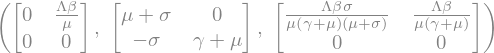

In [9]:
seir.F, seir.V, seir.K

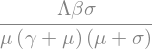

In [10]:
seir.R0

In [11]:
print(seir.latex())

\frac{\Lambda \beta \sigma}{\mu \left(\gamma + \mu\right) \left(\mu + \sigma\right)}


In [12]:
import sympy as sp 
print(sp.latex(seir.F))
print(sp.latex(seir.V))
print(sp.latex(seir.K))


\left[\begin{matrix}0 & \frac{\Lambda \beta}{\mu}\\0 & 0\end{matrix}\right]
\left[\begin{matrix}\mu + \sigma & 0\\- \sigma & \gamma + \mu\end{matrix}\right]
\left[\begin{matrix}\frac{\Lambda \beta \sigma}{\mu \left(\gamma + \mu\right) \left(\mu + \sigma\right)} & \frac{\Lambda \beta}{\mu \left(\gamma + \mu\right)}\\0 & 0\end{matrix}\right]


### Sensitivity indices

$\Upsilon_p = \dfrac{\partial R_0}{\partial p}\dfrac{p}{R_0}$: a 1% increase in $p$ changes $R_0$ by $\Upsilon_p$%.

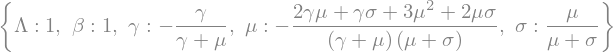

In [13]:
seir.sensitivity_indices()

In [14]:
values = {"Lambda": 10, "beta": 0.001, "sigma": 0.2, "gamma": 0.1, "mu": 0.02}
print("R0 =", seir.R0_numeric(values))
seir.sensitivity_indices(values)

R0 = 3.787878787878788


## 2. Classic SIR (closed population)

Without births the disease-free equilibrium is not unique, so the susceptible population at the DFE is given.

In [15]:
sir = R0Model({"S": "-beta*S*I/N",
               "I": "beta*S*I/N - gamma*I",
               "R": "gamma*I"}, infected=["I"], dfe={"S": "N"})
sir.R0

Without `dfe`, the error says exactly what is missing:

In [16]:
try:
    R0Model({"S": "-beta*S*I/N", "I": "beta*S*I/N - gamma*I", "R": "gamma*I"}, infected=["I"])
except Exception as e:
    print(type(e).__name__, "->", e)

DiseaseFreeEquilibriumError -> The disease-free value of ['S'] is not determined by the equations (e.g. a closed population without births). Provide it with dfe={'S': ...}.


In [17]:
from IPython.display import Markdown, display
display(Markdown(sir.report_latex("markdown")))

## pyR0compute: next-generation matrix method

**Variables:** $S, I, R$  
**Infected compartments:** $I$  
**Parameters (detected automatically):** $N, \beta, \gamma$

### Model

$$
\begin{aligned}
\frac{dS}{dt} &= - \frac{I S \beta}{N} \\
\frac{dI}{dt} &= - I \gamma + \frac{I S \beta}{N} \\
\frac{dR}{dt} &= I \gamma
\end{aligned}
$$

### New-infection terms (automatic)

$$
\begin{aligned}
\mathcal{F}_{I} &= \frac{I S \beta}{N}
\end{aligned}
$$

### Term classification

| Equation | Term | Class | Reason |
|---|---|:---:|---|
| $dI/dt$ | $- I \gamma$ | $\mathcal{V}$ | negative term |
| $dI/dt$ | $\frac{I S \beta}{N}$ | $\mathcal{F}$ | transfer from uninfected S |

### Transition terms

$$
\begin{aligned}
\mathcal{V}_{I} &= I \gamma
\end{aligned}
$$

### Disease-free equilibrium

$$
\begin{aligned}
S &= N \\
I &= 0 \\
R &= R
\end{aligned}
$$

### Next-generation matrix

$$
\begin{aligned}
F &= \begin{bmatrix}\beta\end{bmatrix} \\
V &= \begin{bmatrix}\gamma\end{bmatrix} \\
K = F V^{-1} &= \begin{bmatrix}\frac{\beta}{\gamma}\end{bmatrix}
\end{aligned}
$$

### Basic reproduction number

$$
\begin{aligned}
\mathcal{R}_0 = \rho\left(F V^{-1}\right) &= \frac{\beta}{\gamma}
\end{aligned}
$$

## 3. Vector-borne disease: Ross-Macdonald model

Parameters detected: (L_h, L_v, N_h, a, b_h, b_v, gamma, mu_h, mu_v)
Disease-free equilibrium: {S_h: L_h/mu_h, I_h: 0, R_h: 0, S_v: L_v/mu_v, I_v: 0}


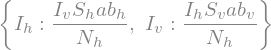

In [18]:
rm = R0Model("""
    dS_h/dt = L_h - a*b_h*S_h*I_v/N_h - mu_h*S_h
    dI_h/dt = a*b_h*S_h*I_v/N_h - (gamma + mu_h)*I_h
    dR_h/dt = gamma*I_h - mu_h*R_h
    dS_v/dt = L_v - a*b_v*S_v*I_h/N_h - mu_v*S_v
    dI_v/dt = a*b_v*S_v*I_h/N_h - mu_v*I_v
""", infected=["I_h", "I_v"])

print("Parameters detected:", rm.parameters)
print("Disease-free equilibrium:", rm.dfe)
rm.new_infections

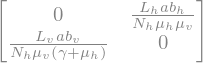

In [19]:
rm.K

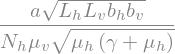

In [20]:
rm.R0

In [21]:
from IPython.display import Markdown, display
display(Markdown(rm.report_latex("markdown")))

## pyR0compute: next-generation matrix method

**Variables:** $S_{h}, I_{h}, R_{h}, S_{v}, I_{v}$  
**Infected compartments:** $I_{h}, I_{v}$  
**Parameters (detected automatically):** $L_{h}, L_{v}, N_{h}, a, b_{h}, b_{v}, \gamma, \mu_{h}, \mu_{v}$

### Model

$$
\begin{aligned}
\frac{dS_{h}}{dt} &= - \frac{I_{v} S_{h} a b_{h}}{N_{h}} + L_{h} - S_{h} \mu_{h} \\
\frac{dI_{h}}{dt} &= - I_{h} \left(\gamma + \mu_{h}\right) + \frac{I_{v} S_{h} a b_{h}}{N_{h}} \\
\frac{dR_{h}}{dt} &= I_{h} \gamma - R_{h} \mu_{h} \\
\frac{dS_{v}}{dt} &= - \frac{I_{h} S_{v} a b_{v}}{N_{h}} + L_{v} - S_{v} \mu_{v} \\
\frac{dI_{v}}{dt} &= \frac{I_{h} S_{v} a b_{v}}{N_{h}} - I_{v} \mu_{v}
\end{aligned}
$$

### New-infection terms (automatic)

$$
\begin{aligned}
\mathcal{F}_{I_{h}} &= \frac{I_{v} S_{h} a b_{h}}{N_{h}} \\
\mathcal{F}_{I_{v}} &= \frac{I_{h} S_{v} a b_{v}}{N_{h}}
\end{aligned}
$$

### Term classification

| Equation | Term | Class | Reason |
|---|---|:---:|---|
| $dI_{h}/dt$ | $I_{h} \left(- \gamma - \mu_{h}\right)$ | $\mathcal{V}$ | negative term |
| $dI_{h}/dt$ | $\frac{I_{v} S_{h} a b_{h}}{N_{h}}$ | $\mathcal{F}$ | transfer from uninfected S_h |
| $dI_{v}/dt$ | $- I_{v} \mu_{v}$ | $\mathcal{V}$ | negative term |
| $dI_{v}/dt$ | $\frac{I_{h} S_{v} a b_{v}}{N_{h}}$ | $\mathcal{F}$ | transfer from uninfected S_v |

### Transition terms

$$
\begin{aligned}
\mathcal{V}_{I_{h}} &= I_{h} \gamma + I_{h} \mu_{h} \\
\mathcal{V}_{I_{v}} &= I_{v} \mu_{v}
\end{aligned}
$$

### Disease-free equilibrium

$$
\begin{aligned}
S_{h} &= \frac{L_{h}}{\mu_{h}} \\
I_{h} &= 0 \\
R_{h} &= 0 \\
S_{v} &= \frac{L_{v}}{\mu_{v}} \\
I_{v} &= 0
\end{aligned}
$$

### Next-generation matrix

$$
\begin{aligned}
F &= \begin{bmatrix}0 & \frac{L_{h} a b_{h}}{N_{h} \mu_{h}}\\\frac{L_{v} a b_{v}}{N_{h} \mu_{v}} & 0\end{bmatrix} \\
V &= \begin{bmatrix}\gamma + \mu_{h} & 0\\0 & \mu_{v}\end{bmatrix} \\
K = F V^{-1} &= \begin{bmatrix}0 & \frac{L_{h} a b_{h}}{N_{h} \mu_{h} \mu_{v}}\\\frac{L_{v} a b_{v}}{N_{h} \mu_{v} \left(\gamma + \mu_{h}\right)} & 0\end{bmatrix}
\end{aligned}
$$

### Basic reproduction number

$$
\begin{aligned}
\mathcal{R}_0 = \rho\left(F V^{-1}\right) &= \frac{a \sqrt{L_{h} L_{v} b_{h} b_{v}}}{N_{h} \mu_{v} \sqrt{\mu_{h} \left(\gamma + \mu_{h}\right)}}
\end{aligned}
$$

## 4. Host-vector model with human-to-human transmission and logistic vectors

The total human population is an auxiliary definition. The model has two disease-free equilibria (with and without vectors); the one with vectors is chosen and both are kept.

/var/folders/03/6qv_0kws2yb878rr206p_0n80000gn/T/ipykernel_42872/135047437.py:1: UserWarning: 2 disease-free equilibria were found; using the one with the most non-zero compartments: {'M_v': -kappa_v*(mu_m + omega - phi_v)/phi_v, 'R_h': Delta_h*theta/(mu_h**2 + mu_h*theta), 'S_h': Delta_h/(mu_h + theta), 'S_v': -kappa_v*omega*(mu_m + omega - phi_v)/(phi_v*(mu_v + zeta))}. Pass dfe={...} to choose another one (all are in model.dfe_candidates).
  hv = R0Model("""


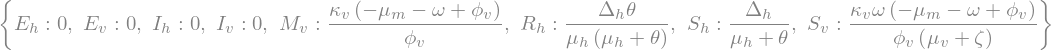

In [22]:
hv = R0Model("""
    N_h = S_h + E_h + I_h + R_h
    dS_h/dt = Delta_h - delta*alpha_hv*S_h*I_v/N_h - beta*alpha_hh*S_h*I_h/N_h - (theta + mu_h)*S_h
    dE_h/dt = delta*alpha_hv*S_h*I_v/N_h + beta*alpha_hh*S_h*I_h/N_h - (sigma + mu_h)*E_h
    dI_h/dt = sigma*E_h - (gamma + mu_h)*I_h
    dR_h/dt = gamma*I_h - mu_h*R_h + theta*S_h
    dM_v/dt = phi_v*M_v*(1 - M_v/kappa_v) - (omega + mu_m)*M_v
    dS_v/dt = omega*M_v - delta*alpha_vh*S_v*I_h/N_h - (mu_v + zeta)*S_v
    dE_v/dt = delta*alpha_vh*S_v*I_h/N_h - (psi + mu_v + zeta)*E_v
    dI_v/dt = psi*E_v - (mu_v + zeta)*I_v
""", infected=["E_h", "I_h", "E_v", "I_v"])
hv.dfe

Only $E_h$ and $E_v$ receive new infections, so $R_0$ is the spectral radius of the $2\times 2$ next-generation matrix with small domain:

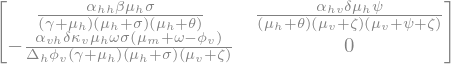

In [23]:
hv.next_generation_matrix_small

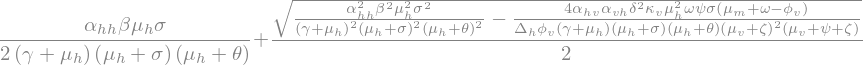

In [24]:
hv.R0

In [25]:
from IPython.display import Markdown, display
display(Markdown(hv.report_latex("markdown")))

## pyR0compute: next-generation matrix method

**Variables:** $S_{h}, E_{h}, I_{h}, R_{h}, M_{v}, S_{v}, E_{v}, I_{v}$  
**Infected compartments:** $E_{h}, I_{h}, E_{v}, I_{v}$  
**Parameters (detected automatically):** $\Delta_{h}, \alpha_{hh}, \alpha_{hv}, \alpha_{vh}, \beta, \delta, \gamma, \kappa_{v}, \mu_{h}, \mu_{m}, \mu_{v}, \omega, \phi_{v}, \psi, \sigma, \theta, \zeta$

### Model

$$
\begin{aligned}
\frac{dS_{h}}{dt} &= \Delta_{h} - \frac{I_{h} S_{h} \alpha_{hh} \beta}{E_{h} + I_{h} + R_{h} + S_{h}} - \frac{I_{v} S_{h} \alpha_{hv} \delta}{E_{h} + I_{h} + R_{h} + S_{h}} - S_{h} \left(\mu_{h} + \theta\right) \\
\frac{dE_{h}}{dt} &= - E_{h} \left(\mu_{h} + \sigma\right) + \frac{I_{h} S_{h} \alpha_{hh} \beta}{E_{h} + I_{h} + R_{h} + S_{h}} + \frac{I_{v} S_{h} \alpha_{hv} \delta}{E_{h} + I_{h} + R_{h} + S_{h}} \\
\frac{dI_{h}}{dt} &= E_{h} \sigma - I_{h} \left(\gamma + \mu_{h}\right) \\
\frac{dR_{h}}{dt} &= I_{h} \gamma - R_{h} \mu_{h} + S_{h} \theta \\
\frac{dM_{v}}{dt} &= M_{v} \phi_{v} \left(- \frac{M_{v}}{\kappa_{v}} + 1\right) - M_{v} \left(\mu_{m} + \omega\right) \\
\frac{dS_{v}}{dt} &= - \frac{I_{h} S_{v} \alpha_{vh} \delta}{E_{h} + I_{h} + R_{h} + S_{h}} + M_{v} \omega - S_{v} \left(\mu_{v} + \zeta\right) \\
\frac{dE_{v}}{dt} &= - E_{v} \left(\mu_{v} + \psi + \zeta\right) + \frac{I_{h} S_{v} \alpha_{vh} \delta}{E_{h} + I_{h} + R_{h} + S_{h}} \\
\frac{dI_{v}}{dt} &= E_{v} \psi - I_{v} \left(\mu_{v} + \zeta\right)
\end{aligned}
$$

### New-infection terms (automatic)

$$
\begin{aligned}
\mathcal{F}_{E_{h}} &= \frac{I_{h} S_{h} \alpha_{hh} \beta}{E_{h} + I_{h} + R_{h} + S_{h}} + \frac{I_{v} S_{h} \alpha_{hv} \delta}{E_{h} + I_{h} + R_{h} + S_{h}} \\
\mathcal{F}_{I_{h}} &= 0 \\
\mathcal{F}_{E_{v}} &= \frac{I_{h} S_{v} \alpha_{vh} \delta}{E_{h} + I_{h} + R_{h} + S_{h}} \\
\mathcal{F}_{I_{v}} &= 0
\end{aligned}
$$

### Term classification

| Equation | Term | Class | Reason |
|---|---|:---:|---|
| $dE_{h}/dt$ | $E_{h} \left(- \mu_{h} - \sigma\right)$ | $\mathcal{V}$ | negative term |
| $dE_{h}/dt$ | $\frac{I_{h} S_{h} \alpha_{hh} \beta}{E_{h} + I_{h} + R_{h} + S_{h}}$ | $\mathcal{F}$ | transfer from uninfected S_h |
| $dE_{h}/dt$ | $\frac{I_{v} S_{h} \alpha_{hv} \delta}{E_{h} + I_{h} + R_{h} + S_{h}}$ | $\mathcal{F}$ | transfer from uninfected S_h |
| $dI_{h}/dt$ | $E_{h} \sigma$ | $\mathcal{V}$ | transfer from infected E_h |
| $dI_{h}/dt$ | $I_{h} \left(- \gamma - \mu_{h}\right)$ | $\mathcal{V}$ | negative term |
| $dE_{v}/dt$ | $E_{v} \left(- \mu_{v} - \psi - \zeta\right)$ | $\mathcal{V}$ | negative term |
| $dE_{v}/dt$ | $\frac{I_{h} S_{v} \alpha_{vh} \delta}{E_{h} + I_{h} + R_{h} + S_{h}}$ | $\mathcal{F}$ | transfer from uninfected S_v |
| $dI_{v}/dt$ | $E_{v} \psi$ | $\mathcal{V}$ | transfer from infected E_v |
| $dI_{v}/dt$ | $I_{v} \left(- \mu_{v} - \zeta\right)$ | $\mathcal{V}$ | negative term |

### Transition terms

$$
\begin{aligned}
\mathcal{V}_{E_{h}} &= E_{h} \mu_{h} + E_{h} \sigma \\
\mathcal{V}_{I_{h}} &= - E_{h} \sigma + I_{h} \gamma + I_{h} \mu_{h} \\
\mathcal{V}_{E_{v}} &= E_{v} \mu_{v} + E_{v} \psi + E_{v} \zeta \\
\mathcal{V}_{I_{v}} &= - E_{v} \psi + I_{v} \mu_{v} + I_{v} \zeta
\end{aligned}
$$

### Disease-free equilibrium

$$
\begin{aligned}
S_{h} &= \frac{\Delta_{h}}{\mu_{h} + \theta} \\
E_{h} &= 0 \\
I_{h} &= 0 \\
R_{h} &= \frac{\Delta_{h} \theta}{\mu_{h} \left(\mu_{h} + \theta\right)} \\
M_{v} &= \frac{\kappa_{v} \left(- \mu_{m} - \omega + \phi_{v}\right)}{\phi_{v}} \\
S_{v} &= \frac{\kappa_{v} \omega \left(- \mu_{m} - \omega + \phi_{v}\right)}{\phi_{v} \left(\mu_{v} + \zeta\right)} \\
E_{v} &= 0 \\
I_{v} &= 0
\end{aligned}
$$

### Next-generation matrix

$$
\begin{aligned}
F &= \begin{bmatrix}0 & \frac{\alpha_{hh} \beta \mu_{h}}{\mu_{h} + \theta} & 0 & \frac{\alpha_{hv} \delta \mu_{h}}{\mu_{h} + \theta}\\0 & 0 & 0 & 0\\0 & - \frac{\alpha_{vh} \delta \kappa_{v} \mu_{h} \omega \left(\mu_{m} + \omega - \phi_{v}\right)}{\Delta_{h} \phi_{v} \left(\mu_{v} + \zeta\right)} & 0 & 0\\0 & 0 & 0 & 0\end{bmatrix} \\
V &= \begin{bmatrix}\mu_{h} + \sigma & 0 & 0 & 0\\- \sigma & \gamma + \mu_{h} & 0 & 0\\0 & 0 & \mu_{v} + \psi + \zeta & 0\\0 & 0 & - \psi & \mu_{v} + \zeta\end{bmatrix} \\
K = F V^{-1} &= \begin{bmatrix}\frac{\alpha_{hh} \beta \mu_{h} \sigma}{\left(\gamma + \mu_{h}\right) \left(\mu_{h} + \sigma\right) \left(\mu_{h} + \theta\right)} & \frac{\alpha_{hh} \beta \mu_{h}}{\left(\gamma + \mu_{h}\right) \left(\mu_{h} + \theta\right)} & \frac{\alpha_{hv} \delta \mu_{h} \psi}{\left(\mu_{h} + \theta\right) \left(\mu_{v} + \zeta\right) \left(\mu_{v} + \psi + \zeta\right)} & \frac{\alpha_{hv} \delta \mu_{h}}{\left(\mu_{h} + \theta\right) \left(\mu_{v} + \zeta\right)}\\0 & 0 & 0 & 0\\- \frac{\alpha_{vh} \delta \kappa_{v} \mu_{h} \omega \sigma \left(\mu_{m} + \omega - \phi_{v}\right)}{\Delta_{h} \phi_{v} \left(\gamma + \mu_{h}\right) \left(\mu_{h} + \sigma\right) \left(\mu_{v} + \zeta\right)} & - \frac{\alpha_{vh} \delta \kappa_{v} \mu_{h} \omega \left(\mu_{m} + \omega - \phi_{v}\right)}{\Delta_{h} \phi_{v} \left(\gamma + \mu_{h}\right) \left(\mu_{v} + \zeta\right)} & 0 & 0\\0 & 0 & 0 & 0\end{bmatrix}
\end{aligned}
$$

Only $E_{h}, E_{v}$ receive new infections, so $\mathcal{R}_0$ is the spectral radius of the next-generation matrix with small domain:

$$
\begin{aligned}
K_{\text{small}} &= \begin{bmatrix}\frac{\alpha_{hh} \beta \mu_{h} \sigma}{\left(\gamma + \mu_{h}\right) \left(\mu_{h} + \sigma\right) \left(\mu_{h} + \theta\right)} & \frac{\alpha_{hv} \delta \mu_{h} \psi}{\left(\mu_{h} + \theta\right) \left(\mu_{v} + \zeta\right) \left(\mu_{v} + \psi + \zeta\right)}\\- \frac{\alpha_{vh} \delta \kappa_{v} \mu_{h} \omega \sigma \left(\mu_{m} + \omega - \phi_{v}\right)}{\Delta_{h} \phi_{v} \left(\gamma + \mu_{h}\right) \left(\mu_{h} + \sigma\right) \left(\mu_{v} + \zeta\right)} & 0\end{bmatrix}
\end{aligned}
$$

### Basic reproduction number

$$
\begin{aligned}
\mathcal{R}_0 = \rho\left(F V^{-1}\right) &= \frac{\alpha_{hh} \beta \mu_{h} \sigma}{2 \left(\gamma + \mu_{h}\right) \left(\mu_{h} + \sigma\right) \left(\mu_{h} + \theta\right)} + \frac{\sqrt{\frac{\alpha_{hh}^{2} \beta^{2} \mu_{h}^{2} \sigma^{2}}{\left(\gamma + \mu_{h}\right)^{2} \left(\mu_{h} + \sigma\right)^{2} \left(\mu_{h} + \theta\right)^{2}} - \frac{4 \alpha_{hv} \alpha_{vh} \delta^{2} \kappa_{v} \mu_{h}^{2} \omega \psi \sigma \left(\mu_{m} + \omega - \phi_{v}\right)}{\Delta_{h} \phi_{v} \left(\gamma + \mu_{h}\right) \left(\mu_{h} + \sigma\right) \left(\mu_{h} + \theta\right) \left(\mu_{v} + \zeta\right)^{2} \left(\mu_{v} + \psi + \zeta\right)}}}{2}
\end{aligned}
$$

## 5. Within-host model: target cells, infected cells and virus

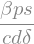

In [26]:
tiv = R0Model("""
    dT/dt = s - d*T - beta*T*V
    dI/dt = beta*T*V - delta*I
    dV/dt = p*I - c*V
""", infected=["I", "V"])
tiv.R0

In [27]:
from IPython.display import Markdown, display
display(Markdown(tiv.report_latex("markdown")))

## pyR0compute: next-generation matrix method

**Variables:** $T, I, V$  
**Infected compartments:** $I, V$  
**Parameters (detected automatically):** $\beta, c, d, \delta, p, s$

### Model

$$
\begin{aligned}
\frac{dT}{dt} &= - T V \beta - T d + s \\
\frac{dI}{dt} &= - I \delta + T V \beta \\
\frac{dV}{dt} &= I p - V c
\end{aligned}
$$

### New-infection terms (automatic)

$$
\begin{aligned}
\mathcal{F}_{I} &= T V \beta \\
\mathcal{F}_{V} &= 0
\end{aligned}
$$

### Term classification

| Equation | Term | Class | Reason |
|---|---|:---:|---|
| $dI/dt$ | $- I \delta$ | $\mathcal{V}$ | negative term |
| $dI/dt$ | $T V \beta$ | $\mathcal{F}$ | transfer from uninfected T |
| $dV/dt$ | $I p$ | $\mathcal{V}$ | transfer from infected I |
| $dV/dt$ | $- V c$ | $\mathcal{V}$ | negative term |

### Transition terms

$$
\begin{aligned}
\mathcal{V}_{I} &= I \delta \\
\mathcal{V}_{V} &= - I p + V c
\end{aligned}
$$

### Disease-free equilibrium

$$
\begin{aligned}
T &= \frac{s}{d} \\
I &= 0 \\
V &= 0
\end{aligned}
$$

### Next-generation matrix

$$
\begin{aligned}
F &= \begin{bmatrix}0 & \frac{\beta s}{d}\\0 & 0\end{bmatrix} \\
V &= \begin{bmatrix}\delta & 0\\- p & c\end{bmatrix} \\
K = F V^{-1} &= \begin{bmatrix}\frac{\beta p s}{c d \delta} & \frac{\beta s}{c d}\\0 & 0\end{bmatrix}
\end{aligned}
$$

Only $I$ receive new infections, so $\mathcal{R}_0$ is the spectral radius of the next-generation matrix with small domain:

$$
\begin{aligned}
K_{\text{small}} &= \begin{bmatrix}\frac{\beta p s}{c d \delta}\end{bmatrix}
\end{aligned}
$$

### Basic reproduction number

$$
\begin{aligned}
\mathcal{R}_0 = \rho\left(F V^{-1}\right) &= \frac{\beta p s}{c d \delta}
\end{aligned}
$$

## 6. van den Driessche & Watmough (2002), treatment model (§4.1)

$p r_2 I$ (treatment failure) is correctly classified as a transition, not a new infection.

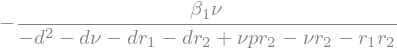

In [28]:
tb = R0Model("""
    N = S + E + I + T
    dE/dt = beta1*S*I/N + beta2*T*I/N - (d + nu + r1)*E + p*r2*I
    dI/dt = nu*E - (d + r2)*I
    dS/dt = b - d*S - beta1*S*I/N
    dT/dt = -d*T + r1*E + q*r2*I - beta2*T*I/N
""", infected=["E", "I"])
tb.R0

In [29]:
from IPython.display import Markdown, display
display(Markdown(tb.report_latex("markdown")))

## pyR0compute: next-generation matrix method

**Variables:** $E, I, S, T$  
**Infected compartments:** $E, I$  
**Parameters (detected automatically):** $b, \beta_{1}, \beta_{2}, d, \nu, p, q, r_{1}, r_{2}$

### Model

$$
\begin{aligned}
\frac{dE}{dt} &= - E \left(d + \nu + r_{1}\right) + \frac{I S \beta_{1}}{E + I + S + T} + \frac{I T \beta_{2}}{E + I + S + T} + I p r_{2} \\
\frac{dI}{dt} &= E \nu - I \left(d + r_{2}\right) \\
\frac{dS}{dt} &= - \frac{I S \beta_{1}}{E + I + S + T} - S d + b \\
\frac{dT}{dt} &= E r_{1} - \frac{I T \beta_{2}}{E + I + S + T} + I q r_{2} - T d
\end{aligned}
$$

### New-infection terms (automatic)

$$
\begin{aligned}
\mathcal{F}_{E} &= \frac{I S \beta_{1}}{E + I + S + T} + \frac{I T \beta_{2}}{E + I + S + T} \\
\mathcal{F}_{I} &= 0
\end{aligned}
$$

### Term classification

| Equation | Term | Class | Reason |
|---|---|:---:|---|
| $dE/dt$ | $E \left(- d - \nu - r_{1}\right)$ | $\mathcal{V}$ | negative term |
| $dE/dt$ | $I p r_{2}$ | $\mathcal{V}$ | transfer from infected I |
| $dE/dt$ | $\frac{I S \beta_{1}}{E + I + S + T}$ | $\mathcal{F}$ | transfer from uninfected S |
| $dE/dt$ | $\frac{I T \beta_{2}}{E + I + S + T}$ | $\mathcal{F}$ | transfer from uninfected T |
| $dI/dt$ | $E \nu$ | $\mathcal{V}$ | transfer from infected E |
| $dI/dt$ | $I \left(- d - r_{2}\right)$ | $\mathcal{V}$ | negative term |

### Transition terms

$$
\begin{aligned}
\mathcal{V}_{E} &= E d + E \nu + E r_{1} - I p r_{2} \\
\mathcal{V}_{I} &= - E \nu + I d + I r_{2}
\end{aligned}
$$

### Disease-free equilibrium

$$
\begin{aligned}
E &= 0 \\
I &= 0 \\
S &= \frac{b}{d} \\
T &= 0
\end{aligned}
$$

### Next-generation matrix

$$
\begin{aligned}
F &= \begin{bmatrix}0 & \beta_{1}\\0 & 0\end{bmatrix} \\
V &= \begin{bmatrix}d + \nu + r_{1} & - p r_{2}\\- \nu & d + r_{2}\end{bmatrix} \\
K = F V^{-1} &= \begin{bmatrix}- \frac{\beta_{1} \nu}{- d^{2} - d \nu - d r_{1} - d r_{2} + \nu p r_{2} - \nu r_{2} - r_{1} r_{2}} & - \frac{\beta_{1} \left(d + \nu + r_{1}\right)}{- d^{2} - d \nu - d r_{1} - d r_{2} + \nu p r_{2} - \nu r_{2} - r_{1} r_{2}}\\0 & 0\end{bmatrix}
\end{aligned}
$$

Only $E$ receive new infections, so $\mathcal{R}_0$ is the spectral radius of the next-generation matrix with small domain:

$$
\begin{aligned}
K_{\text{small}} &= \begin{bmatrix}- \frac{\beta_{1} \nu}{- d^{2} - d \nu - d r_{1} - d r_{2} + \nu p r_{2} - \nu r_{2} - r_{1} r_{2}}\end{bmatrix}
\end{aligned}
$$

### Basic reproduction number

$$
\begin{aligned}
\mathcal{R}_0 = \rho\left(F V^{-1}\right) &= - \frac{\beta_{1} \nu}{- d^{2} - d \nu - d r_{1} - d r_{2} + \nu p r_{2} - \nu r_{2} - r_{1} r_{2}}
\end{aligned}
$$

## 7. Two strains with superinfection

Which strain dominates depends on the parameters, so $R_0$ is the maximum of the strain-specific numbers.

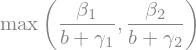

In [30]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    two = R0Model("""
        dI1/dt = beta1*I1*S - (b + gamma1)*I1 + nu*I1*I2
        dI2/dt = beta2*I2*S - (b + gamma2)*I2 - nu*I1*I2
        dS/dt = b - b*S + gamma1*I1 + gamma2*I2 - (beta1*I1 + beta2*I2)*S
    """, infected=["I1", "I2"])
    R0 = two.R0
R0

## 8. Your own model

Replace the equations and the infected compartments. If the automatic split into new infections and transitions is not the one you want, use `new_infections={...}`; to fix the disease-free equilibrium, use `dfe={...}`.

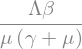

In [31]:
model = R0Model("""
    dS/dt = Lambda - beta*S*I - mu*S
    dI/dt = beta*S*I - (gamma + mu)*I
""", infected=["I"])
model.R0

In [32]:
print(model.latex())

\frac{\Lambda \beta}{\mu \left(\gamma + \mu\right)}


In [33]:
from IPython.display import Markdown, display
display(Markdown(model.report_latex("markdown")))

## pyR0compute: next-generation matrix method

**Variables:** $S, I$  
**Infected compartments:** $I$  
**Parameters (detected automatically):** $\Lambda, \beta, \gamma, \mu$

### Model

$$
\begin{aligned}
\frac{dS}{dt} &= - I S \beta + \Lambda - S \mu \\
\frac{dI}{dt} &= I S \beta - I \left(\gamma + \mu\right)
\end{aligned}
$$

### New-infection terms (automatic)

$$
\begin{aligned}
\mathcal{F}_{I} &= I S \beta
\end{aligned}
$$

### Term classification

| Equation | Term | Class | Reason |
|---|---|:---:|---|
| $dI/dt$ | $I \left(- \gamma - \mu\right)$ | $\mathcal{V}$ | negative term |
| $dI/dt$ | $I S \beta$ | $\mathcal{F}$ | transfer from uninfected S |

### Transition terms

$$
\begin{aligned}
\mathcal{V}_{I} &= I \gamma + I \mu
\end{aligned}
$$

### Disease-free equilibrium

$$
\begin{aligned}
S &= \frac{\Lambda}{\mu} \\
I &= 0
\end{aligned}
$$

### Next-generation matrix

$$
\begin{aligned}
F &= \begin{bmatrix}\frac{\Lambda \beta}{\mu}\end{bmatrix} \\
V &= \begin{bmatrix}\gamma + \mu\end{bmatrix} \\
K = F V^{-1} &= \begin{bmatrix}\frac{\Lambda \beta}{\mu \left(\gamma + \mu\right)}\end{bmatrix}
\end{aligned}
$$

### Basic reproduction number

$$
\begin{aligned}
\mathcal{R}_0 = \rho\left(F V^{-1}\right) &= \frac{\Lambda \beta}{\mu \left(\gamma + \mu\right)}
\end{aligned}
$$